#IS 470 Lab 10: Association Rule Mining

---
Market basket analysis is used behind the scenes for the recommendation systems
used in many brick-and-mortar and online retailers. The learned association rules indicate the combinations of items that are often purchased together. Knowledge of these patterns provides insight into new ways a grocery chain might optimize the inventory, advertise promotions,or organize the physical layout of the store. For instance, if shoppers frequently purchase coffee or orange juice with a breakfast pastry, it may be possible to increase profit by relocating pastries closer to coffee and juice.<br>
<br>
In this lab, we will perform a market basket analysis of transactional data
from a grocery store.Our market basket analysis will utilize the purchase data
collected from one month of operation at a real-world grocery store. The data contains 9,835 transactions.<br>
<br>

###1. Upload and clean data

In [1]:
# Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Import libraries
! pip install apyori
import pandas as pd
import numpy as np
from csv import reader
import seaborn as sns
from apyori import apriori

  Preparing metadata (setup.py) ... done
  Created wheel for apyori: filename=apyori-1.1.2-py3-none-any.whl size=5954 sha256=dfab91420f534c68b0ee5e1e75b8f959a8a80e778bd3b3eecb8d93ed7d3d741a
  Stored in directory: /root/.cache/pip/wheels/7f/49/e3/42c73b19a264de37129fadaa0c52f26cf50e87de08fb9804af
Successfully built apyori


In [3]:
# Read data line by line
groceries = []
with open('/content/drive/MyDrive/IS470_data/groceries.csv', 'r') as read_obj:
    csv_reader = reader(read_obj)
    for row in csv_reader:
        groceries.append(row)

In [4]:
# Inspect the first 5 transactions
groceries[:5]

[['citrus fruit', 'semi-finished bread', 'margarine', 'ready soups'],
 ['tropical fruit', 'yogurt', 'coffee'],
 ['whole milk'],
 ['pip fruit', 'yogurt', 'cream cheese ', 'meat spreads'],
 ['other vegetables',
  'whole milk',
  'condensed milk',
  'long life bakery product']]

## 2. Data exploration

In [5]:
# Show the number of transactions
len(groceries)

9835

In [6]:
# Show the number of unique items
flat_list = np.concatenate(groceries).flat
unique_item, item_count = np.unique(flat_list, return_counts=True)
print("number of unique items:", len(unique_item))

number of unique items: 169


<Axes: xlabel='transaction_len', ylabel='count'>

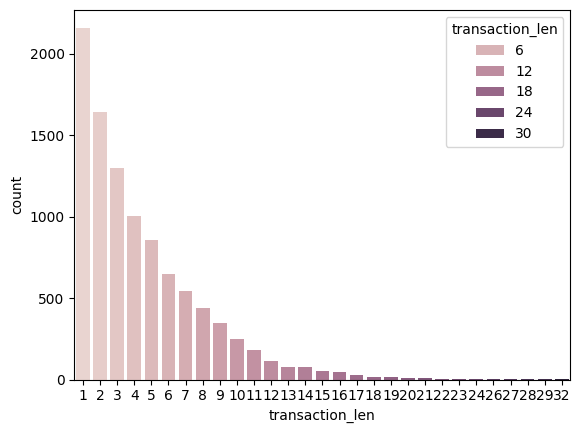

In [7]:
# Plot the distribution of transaction length
transaction_len = []
for transaction in groceries:
  transaction_len.append(len(transaction))
sns.countplot(x = 'transaction_len', hue = 'transaction_len', data = pd.DataFrame({'transaction_len':transaction_len}))

In [8]:
# Examine the absolute frquency of items in descending order
item_frequency = pd.DataFrame({'items':flat_list})
item_frequency.value_counts()

,count
items,
whole milk,2513
other vegetables,1903
rolls/buns,1809
soda,1715
yogurt,1372
...,...
bags,4
kitchen utensil,4
preservation products,2


Q1. What are the top 3 most frequent items?<br>  Whole milk, Other Vegetables, Rolls/buns




In [9]:
# Examine the relative frquency of items in descending order
item_frequency.value_counts()/len(groceries)

,count
items,
whole milk,0.255516
other vegetables,0.193493
rolls/buns,0.183935
soda,0.174377
yogurt,0.139502
...,...
bags,0.000407
kitchen utensil,0.000407
preservation products,0.000203


Q2. What are the support values for top 3 most frequent items?<br/><br/>Whole Milk = 2513/9835 or 0.26<br/>Other Vegetables = 1903/9835 or 0.19<br/>Rolls/Buns = 1809/9835 or 0.18

## 3. Use the apriori algorithm to generate association rules

In [10]:
# Use the apriori command to generate rules with minimal support = 0.01, minimal confidence = 0.3, and max length = 2.
groceries_rules = apriori(groceries, min_support = 0.01, min_confidence = 0.3, max_length=2)
groceries_rules = list(groceries_rules)

In [11]:
# Display all rules
all_rules = pd.DataFrame(columns=('LHS','RHS','support','confidence','lift'))
for i in range(len(groceries_rules)):
  for rule_ in groceries_rules[i].ordered_statistics:
    """
    Maybe some day we'll learn to write code that is not unreadabe garbage?

    The following was commented out, and I wanted to actually understand it, so I formatted it

    all_rules = all_rules.append({
      'LHS': ','.join(list(rule_.items_base)),
      'RHS': ','.join(list(rule_.items_add)),
      'support': groceries_rules[i].support,
      'confidence': rule_.confidence,
      'lift': rule_.lift
    }, ignore_index=True)

    Was that so difficult?
    """
    all_rules = pd.concat([all_rules,
      pd.DataFrame({
        'LHS':[','.join(list(rule_.items_base))],
        'RHS':[','.join(list(rule_.items_add))],
        'support': [groceries_rules[i].support],
        'confidence': [rule_.confidence],
        'lift': [rule_.lift]
      })
    ],ignore_index=True)

    # Note, also formated so you can tell what is going on...

pd.options.display.max_rows = 999
all_rules

/tmp/ipython-input-3128666649.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_rules = pd.concat([all_rules,


,LHS,RHS,support,confidence,lift
0,beef,other vegetables,0.019725,0.375969,1.943066
1,beef,root vegetables,0.017387,0.331395,3.040367
2,beef,whole milk,0.021251,0.405039,1.585180
3,berries,other vegetables,0.010269,0.308869,1.596280
4,berries,whole milk,0.011795,0.354740,1.388328
5,berries,yogurt,0.010574,0.318043,2.279848
6,bottled water,whole milk,0.034367,0.310948,1.216940
7,brown bread,whole milk,0.025216,0.388715,1.521293
8,butter,other vegetables,0.020031,0.361468,1.868122
9,butter,whole milk,0.027555,0.497248,1.946053


Q3. How many rules are generated?<br>68

In [12]:
# Display all rules sorted by confidence levels
all_rules.sort_values(by ='confidence', ascending = False)

,LHS,RHS,support,confidence,lift
9,butter,whole milk,0.027555,0.497248,1.946053
22,curd,whole milk,0.026131,0.490458,1.919481
27,domestic eggs,whole milk,0.029995,0.472756,1.850203
44,onions,other vegetables,0.014235,0.459016,2.372268
66,whipped/sour cream,whole milk,0.032232,0.449645,1.759754
60,root vegetables,whole milk,0.048907,0.448694,1.756031
63,sugar,whole milk,0.015048,0.444444,1.739400
35,hamburger meat,whole milk,0.014743,0.443425,1.735410
33,ham,whole milk,0.011490,0.441406,1.727509
62,sliced cheese,whole milk,0.010778,0.439834,1.721356


In [13]:
# Display the top 5 rules sorted by confidence levels
all_rules.sort_values(by ='confidence', ascending = False)[:5]

,LHS,RHS,support,confidence,lift
9,butter,whole milk,0.027555,0.497248,1.946053
22,curd,whole milk,0.026131,0.490458,1.919481
27,domestic eggs,whole milk,0.029995,0.472756,1.850203
44,onions,other vegetables,0.014235,0.459016,2.372268
66,whipped/sour cream,whole milk,0.032232,0.449645,1.759754


Q4. What is the probability of buying whole milk when butter is purchased?<br>49.7%

Q5. What is the probability of buying butter and whole milk together?<br>2.76%

Q6. Interpret the first rule based on the values of the support, confidence, and lift.<br/><br/>
**Support:** about 2.76 of all transactions contain both butter and whole milk<br/><br/>
**Confidence:** when a customer buys butter there is a 49.7% chance they will also buy whole milk<br/><br/>
**Lift:** butter and whole milk are positively associated, in fact when customers buy butter, they are about 1.95 times more likely to also buy whole milk

In [14]:
# Use the apriori command to generate rules with minimal support = 0.02 and minimal confidence = 0.4 and max length = 3.
groceries_rules2 = apriori(groceries, min_support = 0.02, min_confidence = 0.4, max_length=3)
groceries_rules2 = list(groceries_rules2)

In [15]:
# Display all rules
all_rules = pd.DataFrame(columns=('LHS','RHS','support','confidence','lift'))
for i in range(len(groceries_rules2)):
  for rule_ in groceries_rules2[i].ordered_statistics:
       all_rules = pd.concat([all_rules, pd.DataFrame({'LHS':[','.join(list(rule_.items_base))],'RHS':[','.join(list(rule_.items_add))], 'support': [groceries_rules[i].support], 'confidence': [rule_.confidence], 'lift': [rule_.lift]})],ignore_index=True)
pd.options.display.max_rows = 999
all_rules

/tmp/ipython-input-2794812754.py:5: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_rules = pd.concat([all_rules, pd.DataFrame({'LHS':[','.join(list(rule_.items_base))],'RHS':[','.join(list(rule_.items_add))], 'support': [groceries_rules[i].support], 'confidence': [rule_.confidence], 'lift': [rule_.lift]})],ignore_index=True)


,LHS,RHS,support,confidence,lift
0,beef,whole milk,0.019725,0.405039,1.585180
1,butter,whole milk,0.017387,0.497248,1.946053
2,curd,whole milk,0.021251,0.490458,1.919481
3,domestic eggs,whole milk,0.010269,0.472756,1.850203
4,frozen vegetables,whole milk,0.011795,0.424947,1.663094
5,margarine,whole milk,0.010574,0.413194,1.617098
6,root vegetables,other vegetables,0.034367,0.434701,2.246605
7,whipped/sour cream,other vegetables,0.025216,0.402837,2.081924
8,root vegetables,whole milk,0.020031,0.448694,1.756031
9,tropical fruit,whole milk,0.027555,0.403101,1.577595


In [16]:
# Display top 10 rules sorted by lift
all_rules.sort_values(by ='lift', ascending = False)[:10]

,LHS,RHS,support,confidence,lift
13,"root vegetables,whole milk",other vegetables,0.017895,0.474012,2.449770
6,root vegetables,other vegetables,0.034367,0.434701,2.246605
7,whipped/sour cream,other vegetables,0.025216,0.402837,2.081924
14,"other vegetables,yogurt",whole milk,0.017590,0.512881,2.007235
1,butter,whole milk,0.017387,0.497248,1.946053
2,curd,whole milk,0.021251,0.490458,1.919481
12,"other vegetables,root vegetables",whole milk,0.017895,0.489270,1.914833
3,domestic eggs,whole milk,0.010269,0.472756,1.850203
10,whipped/sour cream,whole milk,0.010371,0.449645,1.759754
8,root vegetables,whole milk,0.020031,0.448694,1.756031


In [17]:
# Find and display rules containing "other vegetables" on the left-hand side
all_rules[all_rules['LHS'].str.contains("other vegetables")]

,LHS,RHS,support,confidence,lift
12,"other vegetables,root vegetables",whole milk,0.017895,0.489270,1.914833
14,"other vegetables,yogurt",whole milk,0.017590,0.512881,2.007235


Q7. Interpret the first rule based on the values of the support, confidence, and lift.<br/><br/>Note: this question is ambiguous.  You say interpret the "First Rule", but it is not clear if you are referring to the rules show directly above this box or the rule with the number 1 on it in the box above (the butter/whole milk rule).  Since that rule was examined earlier, I am going to assume your question is regarding rule #12 (directly above) because that is the first rule in that box<br/><br/>
**Support:** about 1.79% of all transactions contain other vegetables, root vegetables and whole milk<br/><br/>**Confidence:** when a customer buys both other vegetables and root vegetables there is a 48.9% chance they will also buy whole milk<br/><br/>**Lift:** Other vegetables and root vegetables (as a pair) are positively associated with whole milk, in fact when customers buy both of those things they are 1.91 times more likely to also buy whole milk


In [18]:
# Find and display rules containing "other vegetables" on the right-hand side
all_rules[all_rules['RHS'].str.contains("other vegetables")]

,LHS,RHS,support,confidence,lift
6,root vegetables,other vegetables,0.034367,0.434701,2.246605
7,whipped/sour cream,other vegetables,0.025216,0.402837,2.081924
13,"root vegetables,whole milk",other vegetables,0.017895,0.474012,2.449770


In [19]:
# Use the apriori command to generate about 30 to 50 association rules. Set your own minimum support and confidence threshold levels.
# Remember if the thresholds are too low, you will get too many rules, or if you set them too high, you may not get any or enough rules.
groceries_rules3 = apriori(groceries, min_support = 0.02, min_confidence = 0.3)
groceries_rules3 = list(groceries_rules3)

In [20]:
# Display all rules
all_rules = pd.DataFrame(columns=('LHS','RHS','support','confidence','lift'))
for i in range(len(groceries_rules3)):
  for rule_ in groceries_rules3[i].ordered_statistics:
       all_rules = pd.concat([all_rules, pd.DataFrame({'LHS':[','.join(list(rule_.items_base))],'RHS':[','.join(list(rule_.items_add))], 'support': [groceries_rules[i].support], 'confidence': [rule_.confidence], 'lift': [rule_.lift]})],ignore_index=True)
pd.options.display.max_rows = 999
all_rules

/tmp/ipython-input-3498513279.py:5: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_rules = pd.concat([all_rules, pd.DataFrame({'LHS':[','.join(list(rule_.items_base))],'RHS':[','.join(list(rule_.items_add))], 'support': [groceries_rules[i].support], 'confidence': [rule_.confidence], 'lift': [rule_.lift]})],ignore_index=True)


,LHS,RHS,support,confidence,lift
0,beef,whole milk,0.019725,0.405039,1.585180
1,bottled water,whole milk,0.017387,0.310948,1.216940
2,brown bread,whole milk,0.021251,0.388715,1.521293
3,butter,other vegetables,0.010269,0.361468,1.868122
4,butter,whole milk,0.011795,0.497248,1.946053
5,citrus fruit,other vegetables,0.010574,0.348894,1.803140
6,citrus fruit,whole milk,0.034367,0.368550,1.442377
7,curd,whole milk,0.025216,0.490458,1.919481
8,domestic eggs,other vegetables,0.020031,0.350962,1.813824
9,domestic eggs,whole milk,0.027555,0.472756,1.850203


In [21]:
# Display all rules sorted by lift
all_rules.sort_values(by ='lift', ascending = False)

,LHS,RHS,support,confidence,lift
33,"other vegetables,whole milk",root vegetables,0.026640,0.309783,2.842082
34,"root vegetables,whole milk",other vegetables,0.026640,0.474012,2.449770
17,root vegetables,other vegetables,0.018709,0.434701,2.246605
19,whipped/sour cream,other vegetables,0.016472,0.402837,2.081924
36,"yogurt,whole milk",other vegetables,0.011490,0.397459,2.054131
35,"other vegetables,yogurt",whole milk,0.011490,0.512881,2.007235
4,butter,whole milk,0.011795,0.497248,1.946053
16,pork,other vegetables,0.030503,0.375661,1.941476
7,curd,whole milk,0.025216,0.490458,1.919481
32,"other vegetables,root vegetables",whole milk,0.026640,0.489270,1.914833


Q8. Select an interesting rule and explain how it can benefit the grocery store.<br/><br/>To me the one that stands out is the relationship between newspapers and whole milk.  Literally all of the other associates seem obvious to me but this one which means you could do something with this information.  The first thought would be to put a small stand with newspapers on it in the dairy section of the store, but you could try different things also.<br/><br/>
Step 1: put the things that are positively associated together and see if that raises the lift even more?<br/><br/>
Step 2: put the things that have positively associated far apart and see if that increases sales of other items which lay in between those things<br/><br/>
Step 3: Determine which of Step 1, or Step 2 resulted in overall more profit for the store and do that.


In [22]:
!jupyter nbconvert "/content/drive/MyDrive/Colab Notebooks/IS470_lab10.ipynb" --to html --output "/content/drive/MyDrive/Output/IS470_Lab10.html"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/IS470_lab10.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 445689 bytes to /content/drive/MyDrive/Output/IS470_Lab10.html
